shape: (140, 140)
min/max: -0.012919272208431067 22.741752865384445


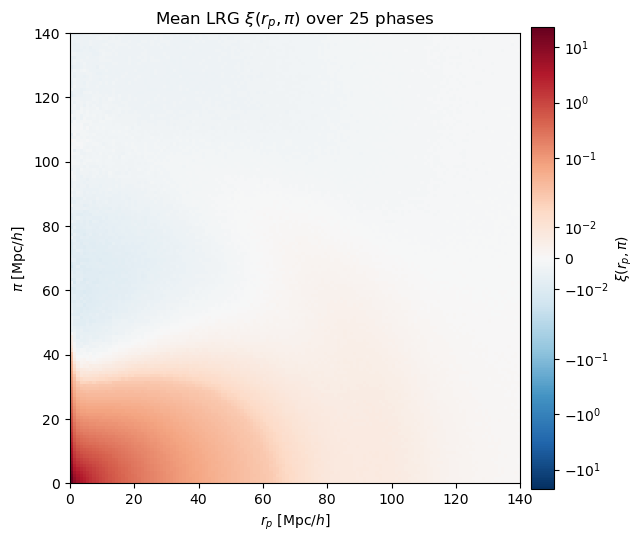

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

OUT = "/pscratch/sd/l/lado/ZeroCrossing/abacus_lrg_mocks"

xi = np.load(f"{OUT}/xirppi_mean.npy")
rp_edges = np.load(f"{OUT}/rp_edges.npy")
pi_edges = np.load(f"{OUT}/pi_edges.npy")

print("shape:", xi.shape)
print("min/max:", xi.min(), xi.max())

# Make the color range symmetric around zero
vabs = max(abs(xi.min()), abs(xi.max()))

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.pcolormesh(
    rp_edges,
    pi_edges,
    xi.T,
    shading="auto",
    cmap="RdBu_r",
    norm=SymLogNorm(
        linthresh=0.02,
        vmin=-vabs,
        vmax= vabs,
    ),
)

ax.set(
    xlabel=r"$r_p\ [{\rm Mpc}/h]$",
    ylabel=r"$\pi\ [{\rm Mpc}/h]$",
    xlim=(0, rp_edges[-1]),
    ylim=(0, pi_edges[-1]),
    aspect="equal",
    title=r"Mean LRG $\xi(r_p,\pi)$ over 25 phases",
)

cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r"$\xi(r_p,\pi)$")

plt.show()

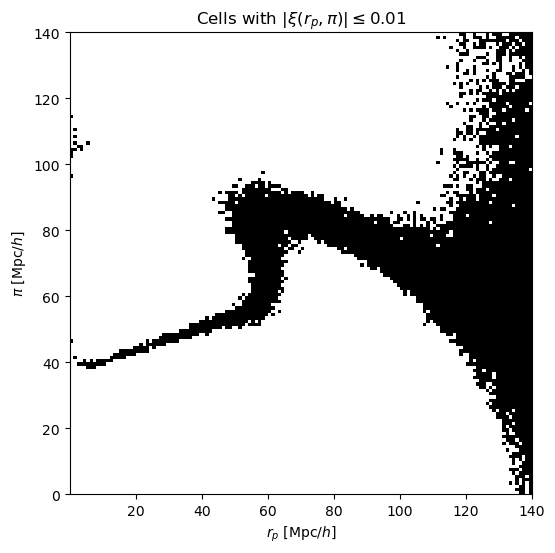

In [15]:
near_zero = (xi >= -0.001) & (xi <= 0.001)

plt.figure(figsize=(7, 6))
plt.pcolormesh(
    rp_edges,
    pi_edges,
    near_zero.T,
    shading="auto",
    cmap=ListedColormap(["white", "black"]),
)
plt.xlabel(r"$r_p\ [{\rm Mpc}/h]$")
plt.ylabel(r"$\pi\ [{\rm Mpc}/h]$")
plt.title(r"Cells with $|\xi(r_p,\pi)| \leq 0.01$")
plt.gca().set_aspect("equal")
plt.show()

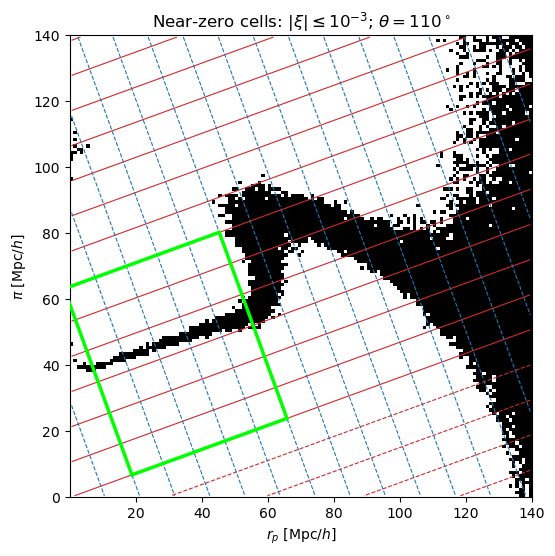

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assumes xi, rp_edges, pi_edges are already loaded
near_zero = (xi >= -0.001) & (xi <= 0.001)

# Bin centers for contour evaluation
rp = 0.5 * (rp_edges[:-1] + rp_edges[1:])
pi = 0.5 * (pi_edges[:-1] + pi_edges[1:])
RP, PI = np.meshgrid(rp, pi, indexing="ij")

# Orientation of first family: normal vector angle
theta_deg = 110.0
spacing = 10.0  # perpendicular spacing in Mpc/h

theta = np.deg2rad(theta_deg)
a1, a2 = np.cos(theta), np.sin(theta)

# Perpendicular family
b1, b2 = -a2, a1

L1 = a1 * RP + a2 * PI
L2 = b1 * RP + b2 * PI

levels = np.arange(-200, 201, spacing)

fig, ax = plt.subplots(figsize=(7, 6))

# Near-zero mask
ax.pcolormesh(
    rp_edges,
    pi_edges,
    near_zero.T,
    shading="auto",
    cmap=ListedColormap(["white", "black"]),
)

# First family: solid red
ax.contour(
    RP, PI, L1,
    levels=levels,
    colors="tab:red",
    linewidths=0.8,
)

# Perpendicular family: dashed blue
ax.contour(
    RP, PI, L2,
    levels=levels,
    colors="tab:blue",
    linewidths=0.8,
    linestyles="--",
)

ax.set(
    xlabel=r"$r_p\ [{\rm Mpc}/h]$",
    ylabel=r"$\pi\ [{\rm Mpc}/h]$",
    xlim=(rp_edges[0], rp_edges[-1]),
    ylim=(pi_edges[0], pi_edges[-1]),
    aspect="equal",
    title=(
        rf"Near-zero cells: $|\xi| \leq 10^{{-3}}$; "
        rf"$\theta={theta_deg:.0f}^\circ$"
    ),
)

from matplotlib.patches import Polygon

# Rectangle limits in rotated coordinates
u_min, u_max = 0.0, 60.0
v_min, v_max = -70.0, -20.0

# Four rectangle corners in (u, v)
uv_corners = np.array([
    [u_min, v_min],
    [u_max, v_min],
    [u_max, v_max],
    [u_min, v_max],
])

# Inverse rotation:
# [rp]   [ a1  -a2 ] [u]
# [pi] = [ a2   a1 ] [v]
Rinv = np.array([
    [ a1, -a2],
    [ a2,  a1],
])

rp_pi_corners = uv_corners @ Rinv.T

rect_rot = Polygon(
    rp_pi_corners,
    closed=True,
    fill=False,
    edgecolor="lime",
    linewidth=2.5,
    zorder=20,
)

ax.add_patch(rect_rot)

plt.show()

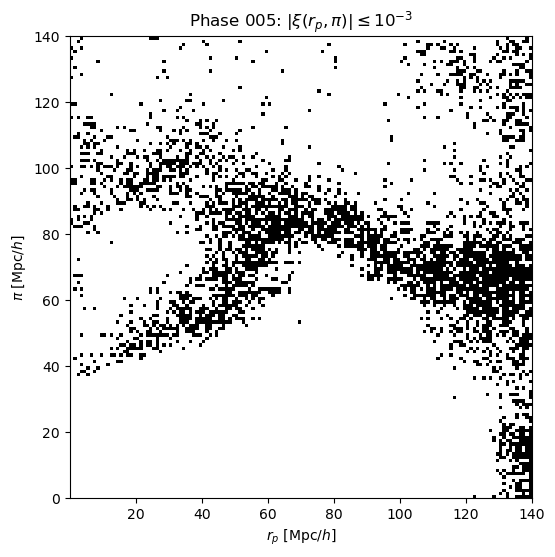

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

OUT = "/pscratch/sd/l/lado/ZeroCrossing/abacus_lrg_mocks"

phase = 5  # change as needed
xi = np.load(f"{OUT}/xirppi_ph{phase:03d}.npy")
rp_edges = np.load(f"{OUT}/rp_edges.npy")
pi_edges = np.load(f"{OUT}/pi_edges.npy")

near_zero = np.abs(xi) <= 0.001

plt.figure(figsize=(7, 6))
plt.pcolormesh(
    rp_edges, pi_edges, near_zero.T,
    shading="auto",
    cmap=ListedColormap(["white", "black"]),
)
plt.xlabel(r"$r_p\ [{\rm Mpc}/h]$")
plt.ylabel(r"$\pi\ [{\rm Mpc}/h]$")
plt.title(rf"Phase {phase:03d}: $|\xi(r_p,\pi)| \leq 10^{{-3}}$")
plt.gca().set_aspect("equal")
plt.show()

best mean xi^2 = 6.443e-07
line length     = 20.5 Mpc/h
normal angle in (u,v) = 93.72 deg
line: cos(phi) u + sin(phi) v = -72.400


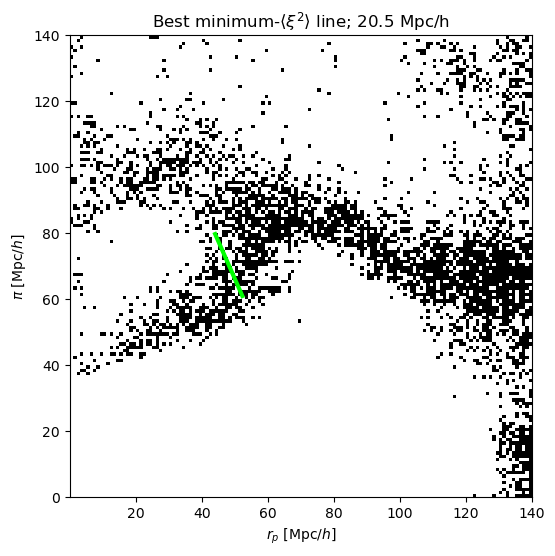

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# Assumes xi, rp_edges, pi_edges are already loaded

# Same rotated coordinates and rectangle as your visualization
theta_deg = 110.0
theta = np.deg2rad(theta_deg)
a1, a2 = np.cos(theta), np.sin(theta)

u_min, u_max = 0.0, 60.0
v_min, v_max = -70.0, -20.0

rp = 0.5 * (rp_edges[:-1] + rp_edges[1:])
pi = 0.5 * (pi_edges[:-1] + pi_edges[1:])
interp = RegularGridInterpolator((rp, pi), xi, bounds_error=False, fill_value=np.nan)

corners = np.array([
    [u_min, v_min],
    [u_min, v_max],
    [u_max, v_min],
    [u_max, v_max],
])

# Candidate-line search settings
n_angle = 121
n_offset = 161
ds = 0.25
min_length = 20.0

D = np.hypot(u_max - u_min, v_max - v_min)
t_grid = np.arange(-D, D + ds, ds)

best_loss = np.inf
best = None

for phi in np.linspace(0, np.pi, n_angle, endpoint=False):

    normal = np.array([np.cos(phi), np.sin(phi)])
    tangent = np.array([-np.sin(phi), np.cos(phi)])

    cmin, cmax = (corners @ normal).min(), (corners @ normal).max()

    for c in np.linspace(cmin, cmax, n_offset):

        # Line in rotated coordinates: normal · (u, v) = c
        uv = c * normal + t_grid[:, None] * tangent

        inside = (
            (uv[:, 0] >= u_min) & (uv[:, 0] <= u_max) &
            (uv[:, 1] >= v_min) & (uv[:, 1] <= v_max)
        )
        uv_line = uv[inside]

        if len(uv_line) < 2:
            continue

        length = (len(uv_line) - 1) * ds
        if length < min_length:
            continue

        # (u,v) -> (rp,pi)
        rp_line = a1 * uv_line[:, 0] - a2 * uv_line[:, 1]
        pi_line = a2 * uv_line[:, 0] + a1 * uv_line[:, 1]

        vals = interp(np.column_stack([rp_line, pi_line]))
        vals = vals[np.isfinite(vals)]

        if len(vals) < 2:
            continue

        # Integral xi^2 ds / length, approximated with equally spaced samples
        loss = np.mean(vals**2)

        if loss < best_loss:
            best_loss = loss
            best = (phi, c, rp_line, pi_line, length)

if best is None:
    raise RuntimeError("No valid line found. Try reducing min_length.")

phi_best, c_best, rp_best, pi_best, length_best = best

print(f"best mean xi^2 = {best_loss:.3e}")
print(f"line length     = {length_best:.1f} Mpc/h")
print(f"normal angle in (u,v) = {np.rad2deg(phi_best):.2f} deg")
print(f"line: cos(phi) u + sin(phi) v = {c_best:.3f}")

# Plot just the black-band visualization plus best line
near_zero = np.abs(xi) <= 0.001

fig, ax = plt.subplots(figsize=(7, 6))
ax.pcolormesh(
    rp_edges, pi_edges, near_zero.T,
    shading="auto", cmap="gray_r",
)

ax.plot(rp_best, pi_best, color="lime", lw=3)

ax.set(
    xlabel=r"$r_p\ [{\rm Mpc}/h]$",
    ylabel=r"$\pi\ [{\rm Mpc}/h]$",
    xlim=(rp_edges[0], rp_edges[-1]),
    ylim=(pi_edges[0], pi_edges[-1]),
    aspect="equal",
    title=rf"Best minimum-$\langle \xi^2\rangle$ line; {length_best:.1f} Mpc/h",
)

plt.show()

In [14]:
import numpy as np
import glob, os
from scipy.interpolate import RegularGridInterpolator

OUT = "/pscratch/sd/l/lado/ZeroCrossing/abacus_lrg_mocks"

# --- Same rotated rectangle as your plot ---
theta_deg = 110.0
theta = np.deg2rad(theta_deg)
a1, a2 = np.cos(theta), np.sin(theta)

u_min, u_max = 0.0, 60.0
v_min, v_max = -70.0, -20.0

# --- Grid and line-search settings ---
rp_edges = np.load(f"{OUT}/rp_edges.npy")
pi_edges = np.load(f"{OUT}/pi_edges.npy")
rp = 0.5 * (rp_edges[:-1] + rp_edges[1:])
pi = 0.5 * (pi_edges[:-1] + pi_edges[1:])

n_angle = 121
n_offset = 161
ds = 0.25
min_length = 20.0

phase_files = sorted(glob.glob(f"{OUT}/xirppi_ph*.npy"))
phase_ids = np.array([
    int(os.path.basename(fn).split("ph")[1].split(".")[0])
    for fn in phase_files
])

# ------------------------------------------------------------------
# Precompute all valid candidate line segments in (u,v), once.
# A candidate is cos(phi) u + sin(phi) v = c.
# ------------------------------------------------------------------
corners_uv = np.array([
    [u_min, v_min], [u_min, v_max],
    [u_max, v_min], [u_max, v_max],
])

candidates = []

for phi in np.linspace(0, np.pi, n_angle, endpoint=False):
    normal = np.array([np.cos(phi), np.sin(phi)])
    tangent = np.array([-np.sin(phi), np.cos(phi)])

    cmin = np.min(corners_uv @ normal)
    cmax = np.max(corners_uv @ normal)

    for c in np.linspace(cmin, cmax, n_offset):
        x0 = c * normal

        # Find exact t interval for x(t) = x0 + t*tangent inside rectangle
        tlo, thi = -np.inf, np.inf

        for j, (lo, hi) in enumerate([(u_min, u_max), (v_min, v_max)]):
            if abs(tangent[j]) < 1e-12:
                if not (lo <= x0[j] <= hi):
                    tlo, thi = 1.0, 0.0
                    break
            else:
                t1 = (lo - x0[j]) / tangent[j]
                t2 = (hi - x0[j]) / tangent[j]
                tlo = max(tlo, min(t1, t2))
                thi = min(thi, max(t1, t2))

        if thi <= tlo:
            continue

        length = thi - tlo
        if length < min_length:
            continue

        t = np.arange(tlo, thi + 0.5 * ds, ds)
        uv = x0 + t[:, None] * tangent

        # (u,v) -> (rp,pi)
        rp_line = a1 * uv[:, 0] - a2 * uv[:, 1]
        pi_line = a2 * uv[:, 0] + a1 * uv[:, 1]

        candidates.append(dict(
            phi=phi,
            c=c,
            length=length,
            rp=rp_line,
            pi=pi_line,
            endpoint0=np.array([rp_line[0],  pi_line[0]]),
            endpoint1=np.array([rp_line[-1], pi_line[-1]]),
        ))

print(f"Testing {len(candidates)} valid line segments for each phase.")

# ------------------------------------------------------------------
# Search every phase
# ------------------------------------------------------------------
best_phi = []
best_c = []
best_loss = []
best_length = []
best_endpoints = []

for ph, fn in zip(phase_ids, phase_files):
    xi = np.load(fn)

    interp = RegularGridInterpolator(
        (rp, pi), xi,
        bounds_error=False,
        fill_value=np.nan,
    )

    loss_min = np.inf
    best = None

    for cand in candidates:
        vals = interp(np.column_stack([cand["rp"], cand["pi"]]))

        if np.any(~np.isfinite(vals)):
            continue

        # Integral xi^2 ds divided by physical line length
        loss = np.mean(vals**2)

        if loss < loss_min:
            loss_min = loss
            best = cand

    if best is None:
        print(f"Phase {ph:03d}: no valid line found")
        best_phi.append(np.nan)
        best_c.append(np.nan)
        best_loss.append(np.nan)
        best_length.append(np.nan)
        best_endpoints.append(np.full((2, 2), np.nan))
    else:
        best_phi.append(best["phi"])
        best_c.append(best["c"])
        best_loss.append(loss_min)
        best_length.append(best["length"])
        best_endpoints.append(np.array([best["endpoint0"], best["endpoint1"]]))

        print(
            f"Phase {ph:03d}: "
            f"phi={np.rad2deg(best['phi']):6.2f} deg, "
            f"c={best['c']:7.3f}, "
            f"loss={loss_min:.3e}"
        )

# ------------------------------------------------------------------
# Final arrays
# ------------------------------------------------------------------
best_phi = np.array(best_phi)                  # normal angle in rotated (u,v)
best_phi_deg = np.rad2deg(best_phi)
best_c = np.array(best_c)                      # cos(phi) u + sin(phi) v = c
best_loss = np.array(best_loss)                # mean xi^2 along best line
best_length = np.array(best_length)
best_endpoints = np.array(best_endpoints)      # (Nphase, 2, 2): [endpoint, (rp,pi)]

# Direction angle of the line itself, rather than its normal:
line_angle_uv_deg = (best_phi_deg + 90.0) % 180.0

print("\nArrays created:")
print("phase_ids            ", phase_ids.shape)
print("best_phi_deg         ", best_phi_deg.shape)
print("line_angle_uv_deg    ", line_angle_uv_deg.shape)
print("best_c               ", best_c.shape)
print("best_loss            ", best_loss.shape)
print("best_length          ", best_length.shape)
print("best_endpoints       ", best_endpoints.shape)

# Optional: save them
np.savez(
    f"{OUT}/zero_line_fits.npz",
    phase_ids=phase_ids,
    best_phi_deg=best_phi_deg,
    line_angle_uv_deg=line_angle_uv_deg,
    best_c=best_c,
    best_loss=best_loss,
    best_length=best_length,
    best_endpoints=best_endpoints,
    theta_deg=theta_deg,
    u_min=u_min, u_max=u_max,
    v_min=v_min, v_max=v_max,
)

Testing 15977 valid line segments for each phase.
Phase 000: phi=177.02 deg, c=-35.812, loss=1.052e-06
Phase 001: phi=178.51 deg, c=-34.605, loss=1.083e-06
Phase 002: phi=178.51 deg, c=-35.754, loss=9.460e-07
Phase 003: phi=177.02 deg, c=-35.421, loss=1.358e-06
Phase 004: phi=172.56 deg, c=-37.222, loss=7.665e-07
Phase 005: phi= 93.72 deg, c=-72.400, loss=6.448e-07
Phase 006: phi=  1.49 deg, c= 31.886, loss=7.144e-07
Phase 007: phi=178.51 deg, c=-33.839, loss=1.297e-06
Phase 008: phi=177.02 deg, c=-36.984, loss=1.224e-06
Phase 009: phi=177.02 deg, c=-35.030, loss=1.556e-06
Phase 010: phi=177.02 deg, c=-36.593, loss=1.081e-06
Phase 011: phi=177.02 deg, c=-37.375, loss=8.383e-07
Phase 012: phi=178.51 deg, c=-34.605, loss=1.557e-06
Phase 013: phi=178.51 deg, c=-37.669, loss=1.262e-06
Phase 014: phi=177.02 deg, c=-35.812, loss=1.008e-06
Phase 015: phi=174.05 deg, c=-37.341, loss=1.136e-06
Phase 016: phi=  2.98 deg, c= 30.750, loss=1.357e-06
Phase 017: phi=  0.00 deg, c= 35.625, loss=9.585e

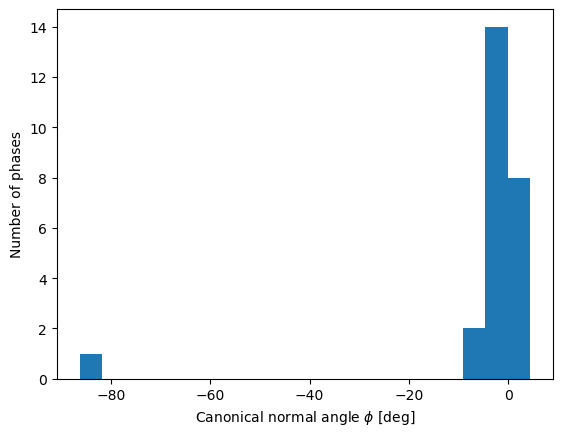

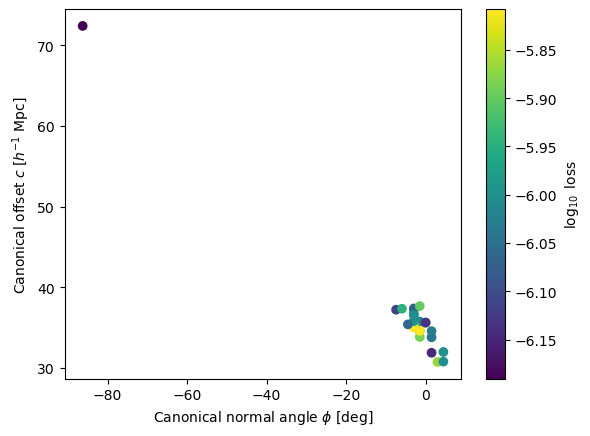

In [16]:
import matplotlib.pyplot as plt

phi_canon_deg = best_phi_deg.copy()
c_canon = best_c.copy()

flip = phi_canon_deg >= 90.0
phi_canon_deg[flip] -= 180.0
c_canon[flip] *= -1.0

plt.hist(phi_canon_deg, bins=20)
plt.xlabel(r"Canonical normal angle $\phi$ [deg]")
plt.ylabel("Number of phases")
plt.show()

plt.scatter(phi_canon_deg, c_canon, c=np.log10(best_loss))
plt.xlabel(r"Canonical normal angle $\phi$ [deg]")
plt.ylabel(r"Canonical offset $c$ [$h^{-1}$ Mpc]")
plt.colorbar(label=r"$\log_{10}$ loss")
plt.show()

f(z=0.5) = 0.757,  beta = 0.505


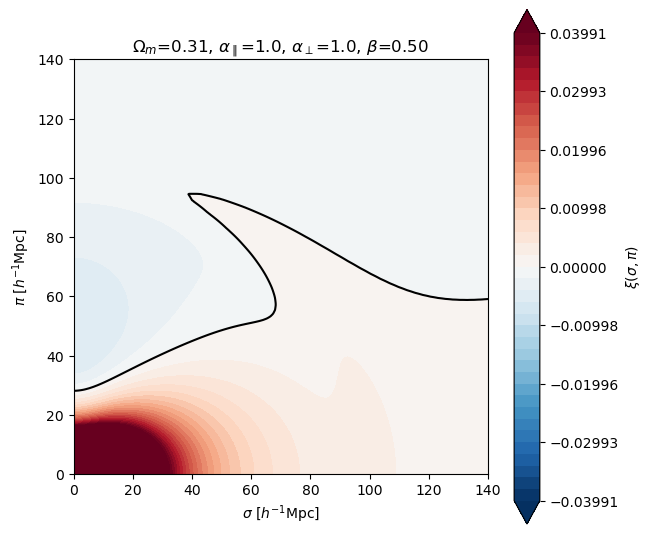

Linear-theory best normal angle phi = 44.628 deg
Linear-theory best c                = -23.395 h^-1 Mpc
Mean xi^2 along line                = 2.5402e-08
Segment length                      = 51.56 h^-1 Mpc
Endpoints [sigma, pi]:
[53.3891893  57.98071597]
[31.32184793 11.44812046]


In [21]:
# pip install camb mcfit
import numpy as np, camb
from mcfit import P2xi
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ----------------- free parameters -----------------
Om         = 0.31     # matter density  (varied via omch2 at fixed h)
alpha_par  = 1.00      # AP stretch along the line of sight (pi)
alpha_perp = 1.00     # AP stretch transverse (sigma)
z          = 0.5      # redshift
bias       = 1.5      # linear bias  ->  beta = f/bias
# fixed cosmology / grid
H0, ombh2, ns, As = 67.7, 0.0224, 0.965, 2.1e-9
smax, ngrid, kmax = 140.0, 281, 20.0
# ---------------------------------------------------

h = H0/100.0
omch2 = Om*h*h - ombh2                      # Om is the knob
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=0.0, omk=0.0)
pars.InitPower.set_params(As=As, ns=ns)
pars.set_matter_power(redshifts=[z], kmax=kmax)
pars.NonLinear = camb.model.NonLinear_none  # linear P(k)
res = camb.get_results(pars)
kh, _, pk = res.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=800)
Pk = pk[0]
f  = (res.get_fsigma8()/res.get_sigma8())[0]   # single z -> unambiguous
beta = f/bias
print(f"f(z={z}) = {f:.3f},  beta = {beta:.3f}")

# clean xi(r) + volume averages via FFTLog (no ringing)
r, xi = P2xi(kh, l=0)(Pk, extrap=True)
c2 = cumulative_trapezoid(xi*r**2, r, initial=0)
c4 = cumulative_trapezoid(xi*r**4, r, initial=0)
xibar, xibarbar = 3*c2/r**3, 5*c4/r**5
f0  = interp1d(r, xi,       bounds_error=False, fill_value=0.0)
fb  = interp1d(r, xibar,    bounds_error=False, fill_value=0.0)
fbb = interp1d(r, xibarbar, bounds_error=False, fill_value=0.0)

# Hamilton linear redshift-space form (overall amplitude is irrelevant to the shape)
C0 = 1 + 2*beta/3 + beta**2/5
C2 = 4*beta/3 + 4*beta**2/7
C4 = 8*beta**2/35

# sigma-pi grid: ONE quadrant (sigma, pi >= 0)
ax = np.linspace(0.0, smax, ngrid)
SIG, PI = np.meshgrid(ax, ax)
st = np.clip(np.sqrt((alpha_perp*SIG)**2 + (alpha_par*PI)**2), 1e-3, None)
mu = (alpha_par*PI)/st
P2 = 0.5*(3*mu**2 - 1)
P4 = (35*mu**4 - 30*mu**2 + 3)/8
XI = C0*f0(st) + C2*(f0(st)-fb(st))*P2 + C4*(f0(st)+2.5*fb(st)-3.5*fbb(st))*P4

# plot (color scale set away from the central spike so structure is visible)
fig, axp = plt.subplots(figsize=(6.6, 5.8))
scale = np.nanpercentile(np.abs(XI[np.add.outer(ax**2, ax**2) > 20**2]), 99)
cf = axp.contourf(ax, ax, XI, levels=np.linspace(-1,1,41)*scale, cmap='RdBu_r', extend='both')
axp.contour(ax, ax, XI, levels=[0], colors='k', linewidths=1.5)         # zero-crossing
axp.set_aspect('equal')
axp.set_xlabel(r'$\sigma\ [h^{-1}\mathrm{Mpc}]$')
axp.set_ylabel(r'$\pi\ [h^{-1}\mathrm{Mpc}]$')
axp.set_title(fr'$\Omega_m$={Om}, $\alpha_\parallel$={alpha_par}, $\alpha_\perp$={alpha_perp}, $\beta$={beta:.2f}')
plt.colorbar(cf, label=r'$\xi(\sigma,\pi)$')
plt.tight_layout(); plt.show()


from scipy.interpolate import RegularGridInterpolator

# ------------------------------------------------------------
# Same rotated coordinates / rectangle as the phase analysis
# ------------------------------------------------------------
theta_deg = 110.0
theta = np.deg2rad(theta_deg)
a1, a2 = np.cos(theta), np.sin(theta)

u_min, u_max = 0.0, 60.0
v_min, v_max = -70.0, -20.0

# XI is indexed as XI[sigma_index, pi_index]
interp = RegularGridInterpolator(
    (ax, ax),
    XI,
    bounds_error=False,
    fill_value=np.nan,
)

corners_uv = np.array([
    [u_min, v_min],
    [u_min, v_max],
    [u_max, v_min],
    [u_max, v_max],
])

# Same search resolution as before
n_angle = 121
n_offset = 161
ds = 0.25
min_length = 20.0

best_loss = np.inf
best = None

for phi in np.linspace(0, np.pi, n_angle, endpoint=False):

    normal = np.array([np.cos(phi), np.sin(phi)])
    tangent = np.array([-np.sin(phi), np.cos(phi)])

    c_min = np.min(corners_uv @ normal)
    c_max = np.max(corners_uv @ normal)

    for c in np.linspace(c_min, c_max, n_offset):

        # Line in rotated coordinates:
        # cos(phi) * u + sin(phi) * v = c
        x0 = c * normal

        # Exact intersection of this line with the u-v rectangle
        t_lo, t_hi = -np.inf, np.inf

        for j, (lo, hi) in enumerate([(u_min, u_max), (v_min, v_max)]):

            if abs(tangent[j]) < 1e-12:
                if not (lo <= x0[j] <= hi):
                    t_lo, t_hi = 1.0, 0.0
                    break
            else:
                t1 = (lo - x0[j]) / tangent[j]
                t2 = (hi - x0[j]) / tangent[j]
                t_lo = max(t_lo, min(t1, t2))
                t_hi = min(t_hi, max(t1, t2))

        if t_hi <= t_lo:
            continue

        length = t_hi - t_lo
        if length < min_length:
            continue

        t = np.arange(t_lo, t_hi + 0.5 * ds, ds)
        uv = x0 + t[:, None] * tangent

        # Inverse rotation: (u,v) -> (sigma, pi)
        sigma_line = a1 * uv[:, 0] - a2 * uv[:, 1]
        pi_line    = a2 * uv[:, 0] + a1 * uv[:, 1]

        vals = interp(np.column_stack([sigma_line, pi_line]))

        if np.any(~np.isfinite(vals)):
            continue

        # Integral xi^2 ds / line length
        loss = np.mean(vals**2)

        if loss < best_loss:
            best_loss = loss
            best = dict(
                phi=phi,
                c=c,
                length=length,
                sigma=sigma_line,
                pi=pi_line,
                endpoint0=np.array([sigma_line[0], pi_line[0]]),
                endpoint1=np.array([sigma_line[-1], pi_line[-1]]),
            )

if best is None:
    raise RuntimeError("No valid line found.")

phi_deg = np.rad2deg(best["phi"])

# Canonicalize: phi and phi+180 deg describe same line.
if phi_deg >= 90:
    phi_deg -= 180
    c_canon = -best["c"]
else:
    c_canon = best["c"]

print(f"Linear-theory best normal angle phi = {phi_deg:.3f} deg")
print(f"Linear-theory best c                = {c_canon:.3f} h^-1 Mpc")
print(f"Mean xi^2 along line                = {best_loss:.4e}")
print(f"Segment length                      = {best['length']:.2f} h^-1 Mpc")
print("Endpoints [sigma, pi]:")
print(best["endpoint0"])
print(best["endpoint1"])

In [22]:
xi = np.load(f"{OUT}/xirppi_mean.npy")

In [23]:
OUT = "/pscratch/sd/l/lado/ZeroCrossing/abacus_lrg_mocks"

xi = np.load(f"{OUT}/xirppi_mean.npy")
rp_edges = np.load(f"{OUT}/rp_edges.npy")
pi_edges = np.load(f"{OUT}/pi_edges.npy")

In [24]:
best_mean = find_best_zero_line(xi, rp_edges, pi_edges)

NameError: name 'find_best_zero_line' is not defined

ph000: phi =  177.02 deg, c =  -35.81
ph001: phi =  178.51 deg, c =  -34.60
ph002: phi =  178.51 deg, c =  -35.75
ph003: phi =  177.02 deg, c =  -35.42
ph004: phi =  172.56 deg, c =  -37.22
ph005: phi =   93.72 deg, c =  -72.40
ph006: phi =    1.49 deg, c =   31.89
ph007: phi =  178.51 deg, c =  -33.84
ph008: phi =  177.02 deg, c =  -36.98
ph009: phi =  177.02 deg, c =  -35.03
ph010: phi =  177.02 deg, c =  -36.59
ph011: phi =  177.02 deg, c =  -37.37
ph012: phi =    0.00 deg, c =   33.75
ph013: phi =  178.51 deg, c =  -37.67
ph014: phi =  177.02 deg, c =  -35.81
ph015: phi =  174.05 deg, c =  -37.34
ph016: phi =    2.98 deg, c =   30.75
ph017: phi =    0.00 deg, c =   35.62
ph018: phi =    1.49 deg, c =   33.80
ph019: phi =  175.54 deg, c =  -35.40
ph020: phi =    4.46 deg, c =   31.98
ph021: phi =    0.00 deg, c =   35.62
ph022: phi =    1.49 deg, c =   34.57
ph023: phi =  177.02 deg, c =  -36.59
ph024: phi =    4.46 deg, c =   30.79
ph000:   17.02 deg
ph001:   18.51 deg
ph002:   18.

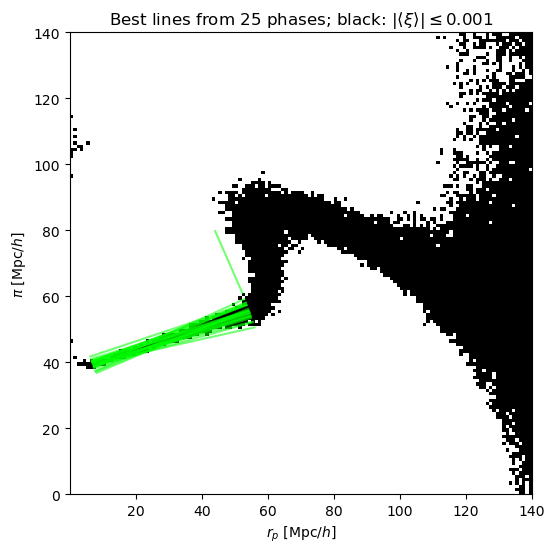

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# Assumes rp_edges and pi_edges are the same for every phase.
# Replace this with your usual phase-loading line.
import h5py

OUT = "/pscratch/sd/l/lado/ZeroCrossing/abacus_lrg_mocks"

def load_xi(phase):
    return np.load(f"{OUT}/xirppi_ph{phase:03d}.npy")

theta = np.deg2rad(110.0)
a1, a2 = np.cos(theta), np.sin(theta)

u_min, u_max = 0.0, 60.0
v_min, v_max = -70.0, -20.0

rp = 0.5 * (rp_edges[:-1] + rp_edges[1:])
pi = 0.5 * (pi_edges[:-1] + pi_edges[1:])

corners = np.array([[u_min, v_min], [u_min, v_max],
                    [u_max, v_min], [u_max, v_max]])

n_angle, n_offset = 121, 161
ds, min_length = 0.25, 20.0
D = np.hypot(u_max - u_min, v_max - v_min)
t_grid = np.arange(-D, D + ds, ds)


def find_best_line(xi):
    interp = RegularGridInterpolator((rp, pi), xi, bounds_error=False, fill_value=np.nan)
    best_loss, best = np.inf, None

    for phi in np.linspace(0, np.pi, n_angle, endpoint=False):
        normal  = np.array([np.cos(phi), np.sin(phi)])
        tangent = np.array([-np.sin(phi), np.cos(phi)])
        cmin, cmax = (corners @ normal).min(), (corners @ normal).max()

        for c in np.linspace(cmin, cmax, n_offset):
            uv = c * normal + t_grid[:, None] * tangent
            uv = uv[
                (uv[:, 0] >= u_min) & (uv[:, 0] <= u_max) &
                (uv[:, 1] >= v_min) & (uv[:, 1] <= v_max)
            ]

            if len(uv) < 2 or (len(uv) - 1) * ds < min_length:
                continue

            rp_line = a1 * uv[:, 0] - a2 * uv[:, 1]
            pi_line = a2 * uv[:, 0] + a1 * uv[:, 1]

            vals = interp(np.c_[rp_line, pi_line])
            vals = vals[np.isfinite(vals)]

            if len(vals) < 2:
                continue

            loss = np.mean(vals**2)

            if loss < best_loss:
                best_loss = loss
                best = (phi, c, rp_line, pi_line)

    return best_loss, best

xis, lines, phis, cs = [], [], [], []

for phase in range(25):
    xi = load_xi(phase)
    loss, best = find_best_line(xi)

    phi, c, rp_line, pi_line = best

    xis.append(xi)
    lines.append((rp_line, pi_line))
    phis.append(phi)
    cs.append(c)

    print(f"ph{phase:03d}: phi = {np.degrees(phi):7.2f} deg, c = {c:7.2f}")
    
xi_mean = np.mean(xis, axis=0)
near_zero_mean = np.abs(xi_mean) <= 0.001

for phase, (rp_line, pi_line) in enumerate(lines):
    angle = np.degrees(np.arctan2(
        pi_line[-1] - pi_line[0],
        rp_line[-1] - rp_line[0],
    )) % 180
    print(f"ph{phase:03d}: {angle:7.2f} deg")
    
fig, ax = plt.subplots(figsize=(7, 6))

ax.pcolormesh(
    rp_edges, pi_edges, near_zero_mean.T,
    shading="auto", cmap="gray_r"
)

for rp_line, pi_line in lines:
    ax.plot(rp_line, pi_line, color="lime", lw=1.5, alpha=0.55)

ax.set(
    xlabel=r"$r_p\ [{\rm Mpc}/h]$",
    ylabel=r"$\pi\ [{\rm Mpc}/h]$",
    xlim=(rp_edges[0], rp_edges[-1]),
    ylim=(pi_edges[0], pi_edges[-1]),
    aspect="equal",
    title=r"Best lines from 25 phases; black: $|\langle\xi\rangle| \leq 0.001$",
)

plt.show()

In [19]:
phi_deg = np.asarray(phis, dtype=float).copy()   # already degrees
c_norm  = np.asarray(cs, dtype=float).copy()

# Equivalent representation of the same line:
# (phi, c) -> (phi + 180 deg, -c)
flip = c_norm > 0
phi_deg[flip] += 180.0
c_norm[flip] *= -1.0

for phase, (phi, c) in enumerate(zip(phi_deg, c_norm)):
    print(f"ph{phase:03d}: phi = {phi:7.2f} deg, c = {c:7.2f}")

ph000: phi =  177.02 deg, c =  -35.81
ph001: phi =  178.51 deg, c =  -34.60
ph002: phi =  178.51 deg, c =  -35.75
ph003: phi =  177.02 deg, c =  -35.42
ph004: phi =  172.56 deg, c =  -37.22
ph005: phi =   93.72 deg, c =  -72.40
ph006: phi =  181.49 deg, c =  -31.89
ph007: phi =  178.51 deg, c =  -33.84
ph008: phi =  177.02 deg, c =  -36.98
ph009: phi =  177.02 deg, c =  -35.03
ph010: phi =  177.02 deg, c =  -36.59
ph011: phi =  177.02 deg, c =  -37.37
ph012: phi =  180.00 deg, c =  -33.75
ph013: phi =  178.51 deg, c =  -37.67
ph014: phi =  177.02 deg, c =  -35.81
ph015: phi =  174.05 deg, c =  -37.34
ph016: phi =  182.98 deg, c =  -30.75
ph017: phi =  180.00 deg, c =  -35.62
ph018: phi =  181.49 deg, c =  -33.80
ph019: phi =  175.54 deg, c =  -35.40
ph020: phi =  184.46 deg, c =  -31.98
ph021: phi =  180.00 deg, c =  -35.62
ph022: phi =  181.49 deg, c =  -34.57
ph023: phi =  177.02 deg, c =  -36.59
ph024: phi =  184.46 deg, c =  -30.79


In [21]:
phis = phi_deg
cs = c_norm

keep = np.arange(25) != 5       # remove ph005
phi_keep = phis[keep]
c_keep = cs[keep]

# Put angles on one continuous branch before taking ordinary means/covariances
phi_ref = np.median(phi_keep)
phi_keep = phi_ref + (phi_keep - phi_ref + 90) % 180 - 90

mean_phi = np.mean(phi_keep)
mean_c = np.mean(c_keep)

cov = np.cov(np.c_[phi_keep, c_keep], rowvar=False, ddof=1)
corr = np.corrcoef(np.c_[phi_keep, c_keep], rowvar=False)

print(f"Using {len(phi_keep)} phases, excluding ph005")
print(f"mean phi = {mean_phi:.3f} deg")
print(f"mean c   = {mean_c:.3f} Mpc/h")

print("\nCovariance matrix:")
print("             phi [deg]        c [Mpc/h]")
print(f"phi     {cov[0,0]:13.6f} {cov[0,1]:15.6f}")
print(f"c       {cov[1,0]:13.6f} {cov[1,1]:15.6f}")

print("\nCorrelation matrix:")
print(corr)

Using 24 phases, excluding ph005
mean phi = 178.698 deg
mean c   = -35.009 Mpc/h

Covariance matrix:
             phi [deg]        c [Mpc/h]
phi          8.911989        5.014505
c            5.014505        4.109052

Correlation matrix:
[[1.         0.82864759]
 [0.82864759 1.        ]]


In [23]:
np.sqrt(8.912)/178.698

np.float64(0.016705823820788404)

In [24]:
np.sqrt(4.109)/35

np.float64(0.057916195613021006)